In [1]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
import ML_amber, inspect, sys, importlib

from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
print("Imported ML.py from:", ML_amber.__file__)

Imported ML.py from: /Users/gregcc/Documents/GitHub/SURP25/Microlensing/ML_amber.py


In [2]:
from ML_amber import ThreeLens1S
from ML_amber import TwoLens1S

In [3]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[0.0155] #paper

u0_list_n = [-0.0155]

t0 = 0
tE = 20
rho = 1.8e-3
rs = rho

secnum = 45
basenum = 2
num_points = 1000

#paper
D_l = 6 #kpc
D_s = 8 #kpc

m1 = 0.3 #Lens Star Mass (Solar Mass)

In [4]:
def Einstein_Radius(M_solar, D_l_kpc, D_s_kpc):
    """
    Computes the Einstein Radius.

    Parameters:
    M_solar : float
        Mass of the lens in Solar masses
    D_l_kpc : float
        Distance to the lens in kpc
    D_s_kpc : float
        Distance to the source in kpc

    Returns:
    R_E : float
        Einstein radius in meters
    theta_E_arcsec : float
        Einstein radius in arcseconds
    theta_E_mas : float
        Einstein radius in milliarcseconds
    """
    # Constants
    c = 3e8            # speed of light in m/s
    G = 6.674e-11      # gravitational constant in N m^2 / kg^2
    M_sun = 1.989e30   # kg
    kpc_to_m = 3.086e19  # meters
    rad_to_arcsec = 206265  # arcsec per radian

    # Convert inputs
    M = M_solar * M_sun
    D_l = D_l_kpc * kpc_to_m
    D_s = D_s_kpc * kpc_to_m
    D_ls = D_s - D_l

    # Einstein radius in meters
    R_E = ((4 * G * M / c**2) * (D_ls * D_l / D_s)) ** 0.5

    # Angular Einstein radius in radians
    theta_E_rad = R_E / D_l

    # Convert to arcsec and mas
    theta_E_arcsec = theta_E_rad * rad_to_arcsec
    theta_E_mas = theta_E_arcsec * 1000

    return R_E, theta_E_arcsec, theta_E_mas

In [5]:
R_E, theta_E_arcsec, theta_E_mas = Einstein_Radius(m1, D_l, D_s)

print(f"Einstein Radius: {R_E:.2e} m")
print(f"Angular Einstein Radius: {theta_E_arcsec:.4f} arcsec")
print(f"Angular Einstein Radius: {theta_E_mas:.2f} mas")

Einstein Radius: 2.86e+11 m
Angular Einstein Radius: 0.0003 arcsec
Angular Einstein Radius: 0.32 mas


In [6]:
#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 0, psi, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag

In [7]:
#binary system
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 0, t_lc= triple_model.highres_t )
A_bin = double_model.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

binary_model = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 0, t_lc= triple_model.highres_t )
B_bin = binary_model.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

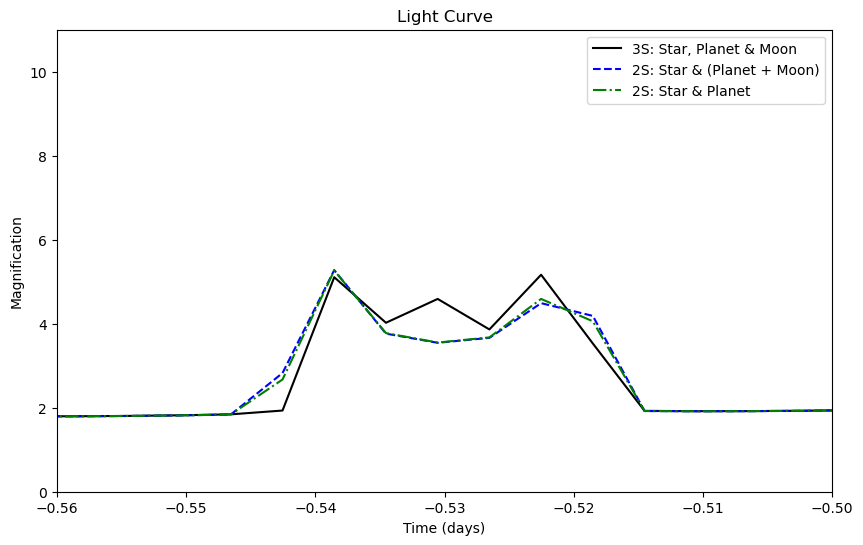

In [8]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_tau, triple_model_mag, 'k-', label = "3S: Star, Planet & Moon")
plt.plot(triple_model_tau, A_bin, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau, B_bin, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel('Time (days)')
plt.ylabel('Magnification')
plt.title('Light Curve')
plt.xlim((-0.56, -0.5))
plt.ylim((0, 11))

plt.legend()

u0=0.0155 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.0155 -0.0155 -0.0155 -0.0155 -0.0155]
u0=0.0155 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.0155 -0.0155 -0.0155 -0.0155 -0.0155]


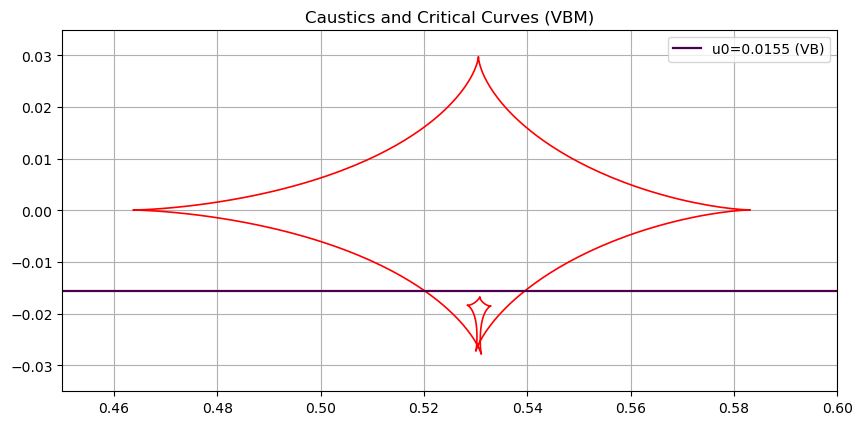

In [9]:
triple_model.plot_caustics_and_critical(show = False)
ax = plt.gca()
ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.035, 0.035)
plt.show()

In [10]:
#Setting Up Centroids
two_system    = double_model.systems[0]
binary_system = binary_model.systems[0]
three_system  = triple_model.systems[0]

# 2L1S 
delta_x_two = two_system['cent_x_lc'] - two_system['y1s_lc']
delta_y_two = two_system['cent_y_lc'] - two_system['y2s_lc']

delta_x_two_B = binary_system['cent_x_lc'] - binary_system['y1s_lc']
delta_y_two_B = binary_system['cent_y_lc'] - binary_system['y2s_lc']

# 3L1S 
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = delta_x_three
delta_y_three = -delta_y_three

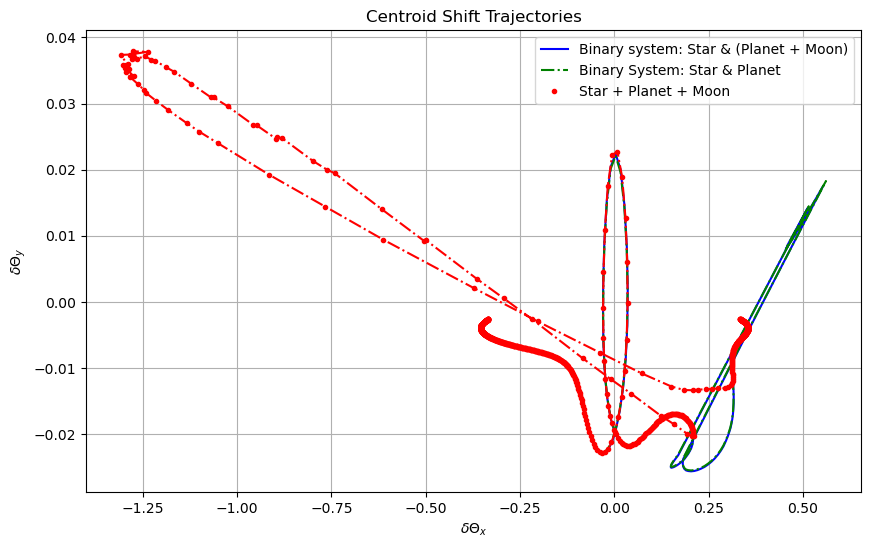

In [11]:
#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two, delta_y_two, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B, delta_y_two_B, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

In [12]:
delta_triple = (delta_x_three**2 + delta_y_three**2)**0.5
delta_double_A = (delta_x_two**2 + delta_y_two**2)**0.5
delta_double_B = (delta_x_two_B**2 + delta_y_two_B**2)**0.5

delta_triple = delta_triple[::-1]


In [13]:
#setting up residual plots
res_triple = delta_double_B - delta_triple
res_double = delta_double_B - delta_double_A

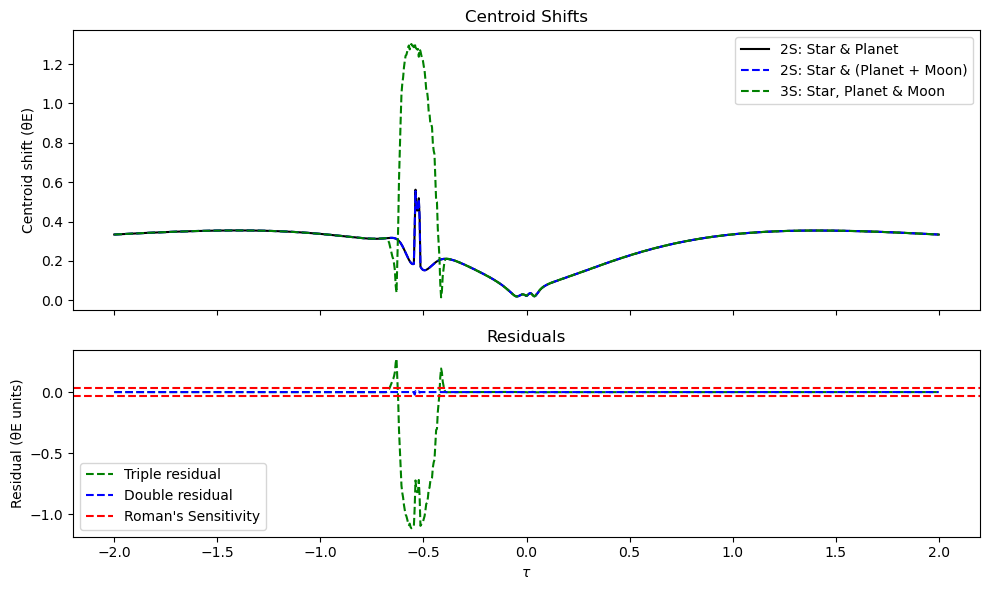

In [14]:
# Roman sensitivity in θE units
thetaE_mas = theta_E_mas
roman_sensitivity = 0.01 / thetaE_mas   # 10 µas = 0.01 mas

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 2]}  # top 3x taller than bottom
)

# --- Top panel: centroid shifts ---
axes[0].plot(triple_model_tau, delta_double_B,'k-', label="2S: Star & Planet")
axes[0].plot(triple_model_tau, delta_double_A, 'b--', label="2S: Star & (Planet + Moon)")
axes[0].plot(triple_model_tau, delta_triple, 'g--', label="3S: Star, Planet & Moon")
axes[0].set_ylabel("Centroid shift (θE)")
axes[0].set_title("Centroid Shifts")
axes[0].legend()

# --- Bottom panel: residuals ---
axes[1].plot(triple_model_tau, res_triple, 'g--', label="Triple residual")
axes[1].plot(triple_model_tau, res_double, 'b--', label="Double residual")
axes[1].axhline(roman_sensitivity, color="red", linestyle="--", label="Roman's Sensitivity")
axes[1].axhline(-roman_sensitivity, color="red", linestyle="--")
axes[1].set_xlabel(r"$\tau$")
axes[1].set_ylabel("Residual (θE units)")
axes[1].set_title("Residuals")
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
s3_1 = .331622776601684
s3_2 = .3225497220955418
s3_3 = .3003845585056752
s3_4 = .27783497862009
s3_5 = .2683772233983162
s3_6 = .2778349786200898
s3_7 = .3003845585056752

psi_1 = 0.00
psi_2 = 0.9687602688129292
psi_3 = 1.393457227228705
psi_4 = 1.0026630929704057
psi_5 = 0.00
psi_6 = -1.0026630929704057
psi_7 = -1.393457227228705

In [16]:
ex1_m = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_1, 0, psi_1, rs, secnum, basenum, num_points)

param = [
    np.log(ex1_m.s2), np.log(ex1_m.q2), ex1_m.u0_list[0], ex1_m.alpha_deg,
    np.log(ex1_m.rho), np.log(ex1_m.tE), ex1_m.t0,
    np.log(ex1_m.s3), np.log(ex1_m.q3), ex1_m.psi_rad
]
mag, *_ = ex1_m.VBM.TripleLightCurve(param, ex1_m.highres_t)

three_system = ex1_m.systems[0]


delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = - delta_x_three
delta_y_three = delta_y_three

ex2 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_2, 0, psi_2, rs, secnum, basenum, num_points)

param = [
    np.log(ex2.s2), np.log(ex2.q2), ex2.u0_list[0], ex2.alpha_deg,
    np.log(ex2.rho), np.log(ex2.tE), ex2.t0,
    np.log(ex2.s3), np.log(ex2.q3), ex2.psi_rad
]
mag, *_ = ex2.VBM.TripleLightCurve(param, ex2.highres_t)

three_system2 = ex2.systems[0]

delta_x_three2 = three_system2['cent_x'] - three_system2['y1s']
delta_y_three2 = three_system2['cent_y'] - three_system2['y2s']

delta_x_three2 = - delta_x_three2
delta_y_three2 = delta_y_three2

ex3 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_3, 0, psi_3, rs, secnum, basenum, num_points)

param = [
    np.log(ex3.s2), np.log(ex3.q2), ex3.u0_list[0], ex3.alpha_deg,
    np.log(ex3.rho), np.log(ex3.tE), ex3.t0,
    np.log(ex3.s3), np.log(ex3.q3), ex3.psi_rad
]
mag, *_ = ex3.VBM.TripleLightCurve(param, ex3.highres_t)

three_system3 = ex3.systems[0]

delta_x_three3 = three_system3['cent_x'] - three_system3['y1s']
delta_y_three3 = three_system3['cent_y'] - three_system3['y2s']

delta_x_three3 = - delta_x_three3
delta_y_three3 = delta_y_three3

ex4 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_4, 0, psi_4, rs, secnum, basenum, num_points)

param = [
    np.log(ex4.s2), np.log(ex4.q2), ex4.u0_list[0], ex4.alpha_deg,
    np.log(ex4.rho), np.log(ex4.tE), ex4.t0,
    np.log(ex4.s3), np.log(ex4.q3), ex4.psi_rad
]
mag, *_ = ex4.VBM.TripleLightCurve(param, ex4.highres_t)

three_system4 = ex4.systems[0]

delta_x_three4 = three_system4['cent_x'] - three_system4['y1s']
delta_y_three4 = three_system4['cent_y'] - three_system4['y2s']

delta_x_three4 = - delta_x_three4
delta_y_three4 = delta_y_three4

ex5 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_5, 0, psi_5, rs, secnum, basenum, num_points)

param = [
    np.log(ex5.s2), np.log(ex5.q2), ex5.u0_list[0], ex5.alpha_deg,
    np.log(ex5.rho), np.log(ex5.tE), ex5.t0,
    np.log(ex5.s3), np.log(ex5.q3), ex5.psi_rad
]
mag, *_ = ex5.VBM.TripleLightCurve(param, ex5.highres_t)

three_system5 = ex5.systems[0]

delta_x_three5 = three_system5['cent_x'] - three_system5['y1s']
delta_y_three5 = three_system5['cent_y'] - three_system5['y2s']

delta_x_three5 = - delta_x_three5
delta_y_three5 = delta_y_three5

ex6 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_6, 0, psi_6, rs, secnum, basenum, num_points)

param = [
    np.log(ex6.s2), np.log(ex6.q2), ex6.u0_list[0], ex6.alpha_deg,
    np.log(ex6.rho), np.log(ex6.tE), ex6.t0,
    np.log(ex6.s3), np.log(ex6.q3), ex6.psi_rad
]
mag, *_ = ex6.VBM.TripleLightCurve(param, ex6.highres_t)

three_system6 = ex6.systems[0]

delta_x_three6 = three_system6['cent_x'] - three_system6['y1s']
delta_y_three6 = three_system6['cent_y'] - three_system6['y2s']

delta_x_three6 = - delta_x_three6
delta_y_three6 = delta_y_three6


In [17]:
ex7 = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3_7, 0, psi_7, rs, secnum, basenum, num_points)

param = [
    np.log(ex7.s2), np.log(ex7.q2), ex7.u0_list[0], ex7.alpha_deg,
    np.log(ex7.rho), np.log(ex7.tE), ex7.t0,
    np.log(ex7.s3), np.log(ex7.q3), ex7.psi_rad
]
mag, *_ = ex7.VBM.TripleLightCurve(param, ex7.highres_t)

three_system7 = ex7.systems[0]

delta_x_three7 = three_system7['cent_x'] - three_system7['y1s']
delta_y_three7 = three_system7['cent_y'] - three_system7['y2s']

In [39]:
delta_x_three = -delta_x_three
delta_y_three = delta_y_three

delta_x_three2 = -delta_x_three2
delta_y_three2 = delta_y_three2

delta_x_three3 = -delta_x_three3
delta_y_three3 = delta_y_three3

delta_x_three4 = -delta_x_three4
delta_y_three4 = delta_y_three4

delta_x_three5 = -delta_x_three5
delta_y_three5 = delta_y_three5

delta_x_three6 = -delta_x_three6
delta_y_three6 = delta_y_three6

delta_x_three7 = -delta_x_three7
delta_y_three7 = delta_y_three7

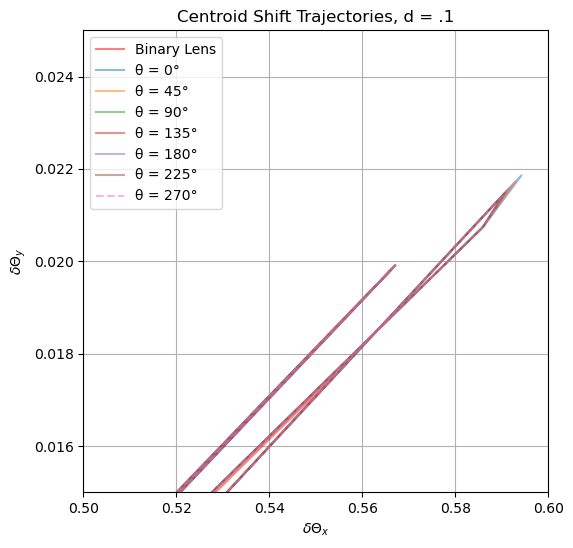

In [41]:
plt.figure(figsize=(6,6))

plt.plot(delta_x_two, delta_y_two, 'r-', label='Binary Lens', alpha = 0.5)


plt.plot(delta_x_three, delta_y_three, '-', label='θ = 0°', alpha = 0.5)
plt.plot(delta_x_three2, delta_y_three2, '-', label='θ = 45°', alpha = 0.5)
plt.plot(delta_x_three3, delta_y_three3, '-', label='θ = 90°', alpha = 0.5)
plt.plot(delta_x_three4, delta_y_three4, '-', label='θ = 135°', alpha = 0.5)
plt.plot(delta_x_three5, delta_y_three5, '-', label='θ = 180°', alpha = 0.5)
plt.plot(delta_x_three6, delta_y_three6, '-', label='θ = 225°', alpha = 0.5)
plt.plot(delta_x_three7, delta_y_three7, '--', label='θ = 270°', alpha = 0.5)


plt.xlim(.5, .6)
plt.ylim(0.015,0.025)

plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories, d = .1")
plt.grid(True)
plt.legend()
plt.show()

u0=0.0155 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.0155 -0.0155 -0.0155 -0.0155 -0.0155]
u0=0.0155 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.0155 -0.0155 -0.0155 -0.0155 -0.0155]


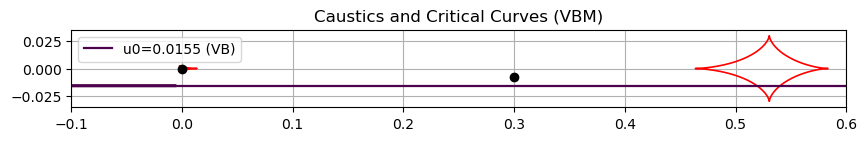

In [20]:
ex7.plot_caustics_and_critical(show = False)
ax = plt.gca()
ax.set_xlim(-0.1, 0.60)
ax.set_ylim(-0.035, 0.035)
plt.show()

In [21]:
delta_triple7 = (delta_x_three7**2 + delta_y_three7**2)**0.5
delta_double_A = (delta_x_two**2 + delta_y_two**2)**0.5
delta_double_B = (delta_x_two_B**2 + delta_y_two_B**2)**0.5

delta_triple7 = delta_triple7[::-1]

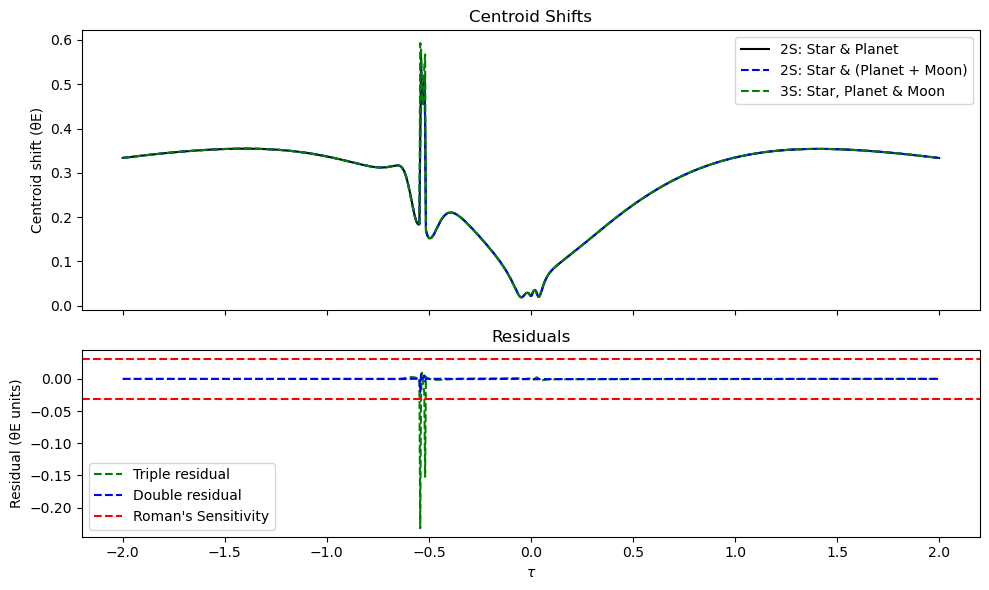

In [22]:
res_triple7 = delta_double_B - delta_triple7

# Roman sensitivity in θE units
thetaE_mas = theta_E_mas
roman_sensitivity = 0.01 / thetaE_mas   # 10 µas = 0.01 mas

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 2]}  # top 3x taller than bottom
)

# --- Top panel: centroid shifts ---
axes[0].plot(triple_model_tau, delta_double_B,'k-', label="2S: Star & Planet")
axes[0].plot(triple_model_tau, delta_double_A, 'b--', label="2S: Star & (Planet + Moon)")
axes[0].plot(triple_model_tau, delta_triple7, 'g--', label="3S: Star, Planet & Moon")
axes[0].set_ylabel("Centroid shift (θE)")
axes[0].set_title("Centroid Shifts")
axes[0].legend()

# --- Bottom panel: residuals ---
axes[1].plot(triple_model_tau, res_triple7, 'g--', label="Triple residual")
axes[1].plot(triple_model_tau, res_double, 'b--', label="Double residual")
axes[1].axhline(roman_sensitivity, color="red", linestyle="--", label="Roman's Sensitivity")
axes[1].axhline(-roman_sensitivity, color="red", linestyle="--")
axes[1].set_xlabel(r"$\tau$")
axes[1].set_ylabel("Residual (θE units)")
axes[1].set_title("Residuals")
axes[1].legend()

plt.tight_layout()
plt.show()